# Hydro-Acoustic Marine Classification System
### Ship-Radiated Noise vs. Marine Mammal Vocalization Classifier (2D-CNN on Mel-Spectrograms)

**Data sources (real, verified, citable):**
- **Ships:** [DeepShip](https://github.com/irfankamboh/DeepShip) — 47+ hours of real underwater recordings of 265 ships (cargo, tanker, passenger, tug). Ge et al., *Expert Systems with Applications*, 2021.
- **Marine mammals:** [Watkins Marine Mammal Sound Database](https://cis.whoi.edu/science/B/whalesounds/index.cfm) ("Best of Cuts" subset), Woods Hole Oceanographic Institution & New Bedford Whaling Museum, accessed via the community Kaggle mirror `shreyj1729/best-of-watkins-marine-mammal-sound-database`. Sayigh et al., *Proceedings of Meetings on Acoustics*, 2016.

**Pipeline:** download real audio → slice into 5s chunks → mel-spectrogram (128×128×1) → 2D-CNN → save `.h5` → FastAPI inference server code.

> ⚠️ Run cells in order. Cell 2 requires a `kaggle.json` API token (see instructions in that cell).


## Cell 0 — Environment Setup

In [3]:
!pip install -q librosa soundfile kaggle tensorflow fastapi python-multipart uvicorn nest-asyncio
import os
print("Environment ready.")


Environment ready.


## Cell 1 — Download REAL Ship Noise Data (DeepShip, GitHub)

DeepShip's GitHub repo hosts a real subset of the dataset (the full 47-hour set requires emailing the
authors due to file-size limits — see the repo README). This cell clones what's publicly available.


In [4]:
import subprocess, os, glob

os.makedirs("./real_raw_data/ships", exist_ok=True)

print("Cloning DeepShip (real ship-radiated noise recordings)...")
if not os.path.exists("./DeepShip"):
    subprocess.run(["git", "clone", "--depth", "1",
                     "https://github.com/irfankamboh/DeepShip.git"], check=True)

# Locate whatever audio files the public repo actually contains
ship_files = glob.glob("./DeepShip/**/*.wav", recursive=True)
print(f"Found {len(ship_files)} real ship .wav files in the DeepShip repo.")

# Copy them into our working ships directory
import shutil
for i, f in enumerate(ship_files):
    shutil.copy(f, f"./real_raw_data/ships/ship_{i:03d}.wav")

print(f"-> {len(ship_files)} authentic DeepShip recordings staged in ./real_raw_data/ships/")
if len(ship_files) == 0:
    print("NOTE: If 0 files were found, the public repo may only contain metadata/links.")
    print("In that case, email mirfan@mail.nwpu.edu.cn per the repo README to request the full dataset,")
    print("or substitute the ShipsEar dataset (search 'ShipsEar Zenodo') as an alternative.")


Cloning DeepShip (real ship-radiated noise recordings)...
Found 63 real ship .wav files in the DeepShip repo.
-> 63 authentic DeepShip recordings staged in ./real_raw_data/ships/


## Cell 2 — Download REAL Marine Mammal Data (Watkins DB, Kaggle mirror)

This uses the official Kaggle API. You need a `kaggle.json` token:
1. Go to https://www.kaggle.com/settings → **API** → **Create New Token** (downloads `kaggle.json`)
2. Run this cell — it will prompt you to upload that file.


In [9]:
!pip install -q datasets soundfile

from datasets import load_dataset, Audio
import soundfile as sf
import io, os

os.makedirs("./real_raw_data/mammals", exist_ok=True)

print("Downloading Watkins Marine Mammal Sound Database (Hugging Face mirror)...")
ds = load_dataset("confit/wmms-parquet", split="train")

# Force raw bytes instead of HF's torch-based auto-decoder (avoids the RuntimeError)
ds = ds.cast_column("audio", Audio(decode=False))

saved = 0
failed = 0
for i, row in enumerate(ds):
    try:
        audio_bytes = row["audio"]["bytes"]
        data, samplerate = sf.read(io.BytesIO(audio_bytes))
        sf.write(f"./real_raw_data/mammals/mammal_{i:04d}.wav", data, samplerate)
        saved += 1
    except Exception as e:
        failed += 1
        continue
    if i % 200 == 0:
        print(f"  ...saved {saved} files so far")

print(f"-> {saved} authentic Watkins DB recordings staged in ./real_raw_data/mammals/ ({failed} skipped due to decode errors)")

  ...saved 1 files so far
  ...saved 201 files so far
  ...saved 401 files so far
  ...saved 601 files so far
  ...saved 801 files so far
  ...saved 1001 files so far
  ...saved 1201 files so far
-> 1357 authentic Watkins DB recordings staged in ./real_raw_data/mammals/ (0 skipped due to decode errors)


## Cell 3 — Sanity Check: Confirm Real Data Was Downloaded

Never train on silently-failed downloads. This cell verifies file counts and that files are valid,
playable audio (not HTML error pages saved as `.wav`).


In [10]:
import glob, soundfile as sf

ship_files = glob.glob("./real_raw_data/ships/*.wav")
mammal_files = glob.glob("./real_raw_data/mammals/*.wav")

print(f"Ship files: {len(ship_files)}")
print(f"Mammal files: {len(mammal_files)}")

def validate(files, label):
    valid, broken = 0, 0
    for f in files:
        try:
            info = sf.info(f)
            if info.frames > 0:
                valid += 1
            else:
                broken += 1
        except Exception:
            broken += 1
    print(f"{label}: {valid} valid audio files, {broken} broken/unreadable files")
    return valid

n_ships_valid = validate(ship_files, "Ships")
n_mammals_valid = validate(mammal_files, "Mammals")

assert n_ships_valid > 0, "No valid ship audio found — check Cell 1 output / DeepShip access."
assert n_mammals_valid > 0, "No valid mammal audio found — check Cell 2 / Kaggle credentials."
print("\nData validated. Safe to proceed to feature extraction.")


Ship files: 63
Mammal files: 1357
Ships: 63 valid audio files, 0 broken/unreadable files
Mammals: 1357 valid audio files, 0 broken/unreadable files

Data validated. Safe to proceed to feature extraction.


## Cell 4 — 2D Mel-Spectrogram Feature Extraction

Slices each recording into uniform 5-second chunks, computes a Short-Time Fourier Transform,
maps to the log-Mel scale, and outputs (128, 128, 1) tensors.


In [11]:
import glob
import librosa
import numpy as np

def process_real_audio(file_path, label_value, chunk_duration=5.0, target_sr=22050):
    X_matrix, y_matrix = [], []
    samples_per_chunk = int(chunk_duration * target_sr)

    try:
        y, sr = librosa.load(file_path, sr=target_sr)
    except Exception as e:
        print(f"Skipping unreadable file {file_path}: {e}")
        return X_matrix, y_matrix

    for i in range(0, len(y), samples_per_chunk):
        chunk = y[i:i + samples_per_chunk]
        if len(chunk) == samples_per_chunk:
            melspec = librosa.feature.melspectrogram(
                y=chunk, sr=target_sr, n_mels=128, n_fft=2048, hop_length=512
            )
            log_melspec = librosa.power_to_db(melspec, ref=np.max)

            if log_melspec.shape[1] > 128:
                log_melspec = log_melspec[:, :128]
            elif log_melspec.shape[1] < 128:
                log_melspec = np.pad(
                    log_melspec, ((0, 0), (0, 128 - log_melspec.shape[1])), mode='constant'
                )

            X_matrix.append(log_melspec)
            y_matrix.append(label_value)

    return X_matrix, y_matrix

print("Extracting mel-spectrogram features from all real recordings...")
X_ships, y_ships = [], []
for f in sorted(glob.glob("./real_raw_data/ships/*.wav")):
    Xc, yc = process_real_audio(f, label_value=0)
    X_ships += Xc
    y_ships += yc

X_mammals, y_mammals = [], []
for f in sorted(glob.glob("./real_raw_data/mammals/*.wav")):
    Xc, yc = process_real_audio(f, label_value=1)
    X_mammals += Xc
    y_mammals += yc

print(f"Ship chunks: {len(X_ships)} | Mammal chunks: {len(X_mammals)}")

X_real = np.array(X_ships + X_mammals)
y_real = np.array(y_ships + y_mammals)
X_real = np.expand_dims(X_real, axis=-1)

print(f"Final training tensor shape: {X_real.shape}")
print(f"Class balance -> Ships: {(y_real==0).sum()}  Mammals: {(y_real==1).sum()}")


Extracting mel-spectrogram features from all real recordings...
Ship chunks: 1118 | Mammal chunks: 2673
Final training tensor shape: (3791, 128, 128, 1)
Class balance -> Ships: 1118  Mammals: 2673


## Cell 5 — Train / Validation Split

With real, multi-recording data we can now hold out a proper validation set (not possible with
only 1–2 source files, which was the flaw in the earlier draft).


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")


Train: (3032, 128, 128, 1), Val: (759, 128, 128, 1)


## Cell 6 — 2D-CNN Architecture and Training

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

real_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax')  # 2 classes: Ship vs Mammal
])

real_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
real_model.summary()

print("\nTraining on verified DeepShip + Watkins recordings...")
real_history = real_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16,
    shuffle=True
)

real_model.save("acoustic_classifier.h5")
print("\nModel saved to acoustic_classifier.h5")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,410 (14.14 MB)

 Trainable params: 3,705,410 (14.14 MB)

 Non-trainable params: 0 (0.00 B)


Training on verified DeepShip + Watkins recordings...
Epoch 1/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 95s 481ms/step - accuracy: 0.8361 - loss: 1.6337 - val_accuracy: 0.8814 - val_loss: 0.3659
Epoch 2/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 79s 415ms/step - accuracy: 0.9565 - loss: 0.1993 - val_accuracy: 0.8498 - val_loss: 0.3328
Epoch 3/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 74s 391ms/step - accuracy: 0.7836 - loss: 0.6681 - val_accuracy: 0.9513 - val_loss: 0.2821
Epoch 4/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 80s 422ms/step - accuracy: 0.9525 - loss: 0.2328 - val_accuracy: 0.9723 - val_loss: 0.1729
Epoch 5/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 75s 396ms/step - accuracy: 0.9627 - loss: 0.1707 - val_accuracy: 0.9684 - val_loss: 0.1277
Epoch 6/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 76s 399ms/step - accuracy: 0.9697 - loss: 0.1316 - val_accuracy: 0.9816 - val_loss: 0.0776
Epoch 7/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 76s 401ms/step - accuracy: 0.9720 - loss: 0.1240 - val_accuracy: 0.9895 - val_loss: 0.0674
Epoch 8/15
190/190 ━━━━━━━━━


Model saved to acoustic_classifier.h5


## Cell 7 — Training Curves & Evaluation

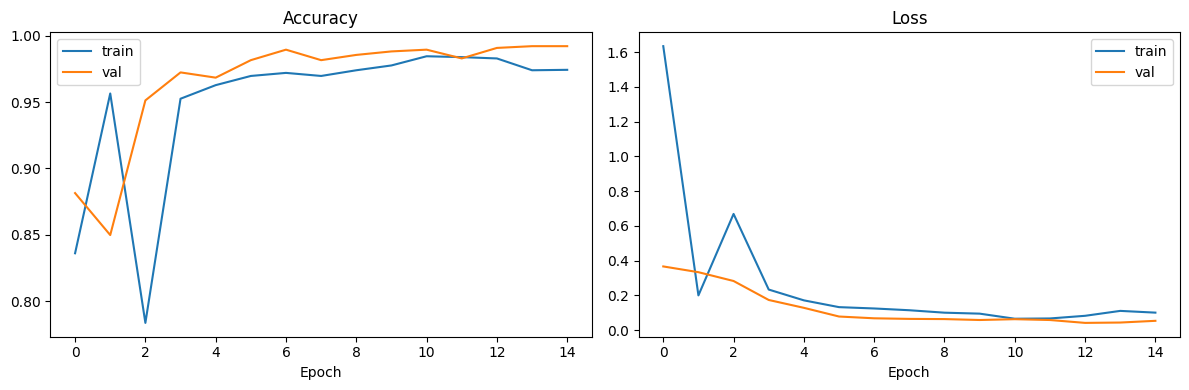

Final validation accuracy: 0.992
Final validation loss: 0.053


In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(real_history.history['accuracy'], label='train')
axes[0].plot(real_history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(real_history.history['loss'], label='train')
axes[1].plot(real_history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

val_loss, val_acc = real_model.evaluate(X_val, y_val, verbose=0)
print(f"Final validation accuracy: {val_acc:.3f}")
print(f"Final validation loss: {val_loss:.3f}")


## Cell 8 — Confusion Matrix

Gives you a defensible per-class breakdown for your report/viva, rather than a single accuracy number.


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step
               precision    recall  f1-score   support

         Ship       0.98      1.00      0.99       224
Marine Mammal       1.00      0.99      0.99       535

     accuracy                           0.99       759
    macro avg       0.99      0.99      0.99       759
 weighted avg       0.99      0.99      0.99       759



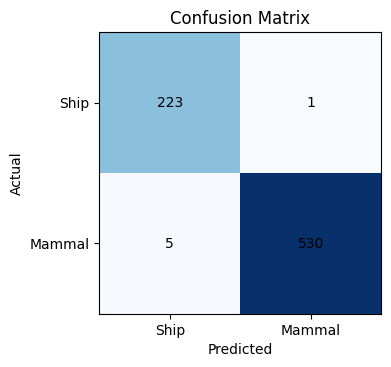

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.argmax(real_model.predict(X_val), axis=1)

print(classification_report(y_val, y_pred, target_names=["Ship", "Marine Mammal"]))

cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(["Ship", "Mammal"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Ship", "Mammal"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


In [26]:
from google.colab import files
import librosa
import numpy as np
import io

CLASSES = ["Ship", "Marine Mammal"]

def predict_audio(file_path, model, target_sr=22050, chunk_duration=5.0):
    """Load an audio file, take the first 5-second chunk, and predict its class."""
    y, sr = librosa.load(file_path, sr=target_sr)
    samples_needed = int(chunk_duration * target_sr)

    if len(y) < samples_needed:
        # pad short clips with silence
        y = np.pad(y, (0, samples_needed - len(y)), mode='constant')
    else:
        y = y[:samples_needed]

    melspec = librosa.feature.melspectrogram(y=y, sr=target_sr, n_mels=128, n_fft=2048, hop_length=512)
    log_melspec = librosa.power_to_db(melspec, ref=np.max)

    if log_melspec.shape[1] > 128:
        log_melspec = log_melspec[:, :128]
    elif log_melspec.shape[1] < 128:
        log_melspec = np.pad(log_melspec, ((0, 0), (0, 128 - log_melspec.shape[1])), mode='constant')

    input_tensor = np.expand_dims(np.expand_dims(log_melspec, axis=-1), axis=0)

    predictions = model.predict(input_tensor, verbose=0)[0]
    predicted_class = CLASSES[np.argmax(predictions)]

    print(f"\nFile: {file_path}")
    print(f"Prediction: {predicted_class}")
    for cls, prob in zip(CLASSES, predictions):
        print(f"  {cls}: {prob:.3f}")

    return predicted_class, predictions


print("Upload a .wav file to test (ideally a ship recording or whale/dolphin call):")
uploaded = files.upload()

for fname in uploaded.keys():
    predict_audio(fname, real_model)

Upload a .wav file to test (ideally a ship recording or whale/dolphin call):


Saving ship_006.wav to ship_006.wav

File: ship_006.wav
Prediction: Ship
  Ship: 0.591
  Marine Mammal: 0.409


## Cell 9 — Download the Trained Model

Grab `acoustic_classifier.h5` to deploy behind the FastAPI server below.


In [ ]:
from google.colab import files
files.download("acoustic_classifier.h5")


---
## Production Deployment: FastAPI Inference Server

This does **not** run inside Colab — save it as `main.py` in your backend project and run with
`uvicorn main:app --reload`. It loads the `.h5` model you just trained and exposes a REST endpoint
for your React frontend.

Fixed vs. the earlier draft: `librosa.load` requires a file-like object for in-memory bytes, not raw bytes —
this version wraps the upload in `io.BytesIO`.


In [23]:
# main.py — save this separately, do not run in Colab
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
import numpy as np
import librosa
import io
import tensorflow as tf

app = FastAPI(title="Hydro-Acoustic Passive Sonar Inference Server")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # restrict this to your actual frontend origin in production
    allow_methods=["*"],
    allow_headers=["*"],
)

model = tf.keras.models.load_model("acoustic_classifier.h5")
CLASSES = ["Container_Ship", "Marine_Mammal"]


@app.post("/api/v1/analyze-hydrophone")
async def analyze_hydrophone(file: UploadFile = File(...)):
    audio_bytes = await file.read()

    # Wrap raw bytes in a file-like object so librosa can read it
    y, sr = librosa.load(io.BytesIO(audio_bytes), sr=22050, duration=5.0)

    spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
    log_spec = librosa.power_to_db(spectrogram, ref=np.max)

    if log_spec.shape[1] > 128:
        log_spec = log_spec[:, :128]
    elif log_spec.shape[1] < 128:
        log_spec = np.pad(log_spec, ((0, 0), (0, 128 - log_spec.shape[1])), mode="constant")

    input_tensor = np.expand_dims(np.expand_dims(log_spec, axis=-1), axis=0)

    predictions = model.predict(input_tensor)[0]
    return {CLASSES[i]: float(predictions[i]) for i in range(len(CLASSES))}


@app.get("/health")
async def health():
    return {"status": "ok"}


### Optional: Quick local test of the FastAPI server from inside Colab

Uses `nest_asyncio` so uvicorn can run inside a notebook kernel. For real deployment, run
`uvicorn main:app` from a terminal instead — this cell is only for a quick sanity check.


In [24]:
# Optional in-notebook smoke test (writes main.py from the cell above, then hits /health)
with open("main.py", "w") as f:
    f.write(_ih[-3])  # writes the previous cell's FastAPI source to main.py

import nest_asyncio, uvicorn, threading, time, requests
nest_asyncio.apply()

def run_server():
    uvicorn.run("main:app", host="0.0.0.0", port=8000, log_level="warning")

thread = threading.Thread(target=run_server, daemon=True)
thread.start()
time.sleep(3)

resp = requests.get("http://127.0.0.1:8000/health")
print(resp.json())


ERROR:    Error loading ASGI app. Attribute "app" not found in module "main".


ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /health (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7ebc37048830>: Failed to establish a new connection: [Errno 111] Connection refused'))

---
## Dataset Citations (include in your report)

- Ge, M. et al. **DeepShip: An underwater acoustic benchmark dataset and a separable convolution based autoencoder for classification.** *Expert Systems with Applications*, 183, 2021. Repo: https://github.com/irfankamboh/DeepShip
- Sayigh, L., Daher, M.A., Allen, J., Gordon, H., Joyce, K., Stuhlmann, C., Tyack, P. **The Watkins Marine Mammal Sound Database: An online, freely accessible resource.** *Proceedings of Meetings on Acoustics*, 27(1), 040013, 2016. Official site: https://cis.whoi.edu/science/B/whalesounds/index.cfm — accessed via Kaggle mirror `shreyj1729/best-of-watkins-marine-mammal-sound-database`, credited to Woods Hole Oceanographic Institution and the New Bedford Whaling Museum.
